<a href="https://colab.research.google.com/github/jupawest/SoSSProject/blob/main/voice_recognition_model5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa numpy soundfile matplotlib scikit-learn

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import lfilter, find_peaks
from scipy.spatial.distance import euclidean
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import Javascript, display, Audio
from base64 import b64decode
import subprocess
from pathlib import Path
from google.colab import output, drive

# ==== Setup ====
drive.mount('/content/drive')
AUDIO_DIR = Path("/content/drive/MyDrive/voice_enrollments")
AUDIO_DIR.mkdir(exist_ok=True)

Mounted at /content/drive


In [2]:
RECORD_JS = """
const sleep = t => new Promise(r=>setTimeout(r,t));
const readBlob = b=>new Promise(r=>{
  const fr = new FileReader();
  fr.onloadend = e => r(e.target.result);
  fr.readAsDataURL(b);
});
var record = t => new Promise(async r=>{
  const stream = await navigator.mediaDevices.getUserMedia({audio:true});
  const rec = new MediaRecorder(stream);
  const chunks = [];
  rec.ondataavailable = e => chunks.push(e.data);
  rec.start();
  await sleep(t);
  rec.stop();
  rec.onstop = async () => r(await readBlob(new Blob(chunks)));
});
"""
def record_audio(sec=3, wav_fn="input.wav"):
    display(Javascript(RECORD_JS))
    data = output.eval_js(f"record({sec*1000})")
    raw_fn = "temp.webm"
    with open(raw_fn, 'wb') as f:
        f.write(b64decode(data.split(',')[1]))
    subprocess.run(['ffmpeg', '-y', '-i', raw_fn, '-ar', '16000', '-ac', '1', wav_fn],
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return wav_fn

In [3]:
def extract_features(path, n_mfcc=13, n_formants=4):
    data, sr = sf.read(path)
    if data.ndim > 1:
        data = np.mean(data, axis=1)  # convert to mono

    # --- Enhanced MFCCs for timbre ---
    mfccs = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfccs.T, axis=0)
    mfcc_std = np.std(mfccs.T, axis=0)  # Add variance info

    # --- Delta and Delta-Delta MFCCs for temporal dynamics ---
    mfcc_delta = librosa.feature.delta(mfccs)
    mfcc_delta_mean = np.mean(mfcc_delta.T, axis=0)

    mfcc_delta2 = librosa.feature.delta(mfccs, order=2)
    mfcc_delta2_mean = np.mean(mfcc_delta2.T, axis=0)

    # --- Enhanced Formants via LPC ---
    def lpc_formants(signal, sr, order=14):  # Increased order
        try:
            a = librosa.lpc(signal, order=order)
            rts = np.roots(a)
            rts = [r for r in rts if np.imag(r) >= 0 and abs(r) < 1]  # More stable roots
            angs = np.arctan2(np.imag(rts), np.real(rts))
            freqs = angs * (sr / (2*np.pi))
            freqs = [f for f in freqs if 80 < f < 4000]  # Human speech range
            freqs.sort()
            # Pad with zeros if we don't have enough formants
            while len(freqs) < n_formants:
                freqs.append(0)
            return freqs[:n_formants]
        except:
            return [0] * n_formants

    formants = lpc_formants(data, sr)

    # --- Enhanced Spectral features ---
    centroid = np.mean(librosa.feature.spectral_centroid(y=data, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=data, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=data, sr=sr))
    contrast = np.mean(librosa.feature.spectral_contrast(y=data, sr=sr))
    flatness = np.mean(librosa.feature.spectral_flatness(y=data))

    # --- Fundamental frequency (F0) features ---
    f0, voiced_flag, voiced_prob = librosa.pyin(data, fmin=librosa.note_to_hz('C2'),
                                               fmax=librosa.note_to_hz('C7'))
    f0_clean = f0[voiced_flag]
    if len(f0_clean) > 0:
        f0_mean = np.nanmean(f0_clean)
        f0_std = np.nanstd(f0_clean)
    else:
        f0_mean = 0
        f0_std = 0

    # --- Chroma features for tonal content ---
    chroma = librosa.feature.chroma_stft(y=data, sr=sr)
    chroma_mean = np.mean(chroma.T, axis=0)

    # --- Zero crossing rate for speech characteristics ---
    zcr = np.mean(librosa.feature.zero_crossing_rate(data))

    # --- Combine all features into one vector ---
    feature_vector = np.concatenate([
        mfcc_mean,            # timbre
        mfcc_std,             # timbre variability
        mfcc_delta_mean,      # phoneme patterns
        mfcc_delta2_mean,     # acceleration patterns
        formants,             # vocal tract resonances
        [centroid, bandwidth, rolloff, contrast, flatness],  # spectral features
        [f0_mean, f0_std],    # pitch characteristics
        chroma_mean,          # tonal content
        [zcr]                 # speech characteristics
    ])

    return feature_vector

In [4]:
def advanced_similarity(feat1, feat2):
    """
    Multi-metric similarity calculation with better discrimination
    """
    # Ensure features are normalized
    feat1_norm = feat1 / (np.linalg.norm(feat1) + 1e-8)
    feat2_norm = feat2 / (np.linalg.norm(feat2) + 1e-8)

    # 1. Cosine similarity (0 to 1)
    cos_sim = cosine_similarity([feat1_norm], [feat2_norm])[0][0]

    # 2. Euclidean distance (converted to similarity)
    eucl_dist = euclidean(feat1_norm, feat2_norm)
    eucl_sim = 1 / (1 + eucl_dist)

    # 3. Correlation coefficient
    corr_coeff = np.corrcoef(feat1, feat2)[0, 1]
    if np.isnan(corr_coeff):
        corr_coeff = 0
    corr_sim = (corr_coeff + 1) / 2  # Convert from [-1,1] to [0,1]

    # Weighted combination (emphasize cosine similarity)
    combined_sim = (0.5 * cos_sim + 0.3 * eucl_sim + 0.2 * corr_sim)

    # Apply more discriminative scaling
    # This makes the similarity more strict
    if combined_sim < 0.7:
        scaled_sim = combined_sim * 0.5  # Reduce low similarities
    else:
        scaled_sim = 0.35 + (combined_sim - 0.7) * 2.17  # Scale high similarities

    return max(0, min(1, scaled_sim))

def normalize_similarity(sim):
    """More discriminative normalization"""
    # Apply sigmoid-like transformation to spread out the scores
    transformed = 1 / (1 + np.exp(-10 * (sim - 0.7)))
    return max(0, min(100, transformed * 100))

def voice_similarity(path1, path2):
    """
    Enhanced voice similarity with better discrimination
    """
    feat1 = extract_features(path1)
    feat2 = extract_features(path2)

    sim = advanced_similarity(feat1, feat2)
    return normalize_similarity(sim)

In [5]:
def plot_waveform_mfcc_formants(path):
    y, sr = librosa.load(path, sr=16000)

    # --- Estimate formants via LPC ---
    def lpc_formants(signal, sr, order=14, n_formants=4):
        try:
            a = librosa.lpc(signal, order)
            rts = np.roots(a)
            rts = [r for r in rts if np.imag(r) >= 0 and abs(r) < 1]
            angs = np.arctan2(np.imag(rts), np.real(rts))
            freqs = angs * (sr / (2*np.pi))
            freqs = [f for f in freqs if 80 < f < 4000]
            freqs.sort()
            return freqs[:n_formants]
        except:
            return []

    formants = lpc_formants(y, sr)

    # --- MFCCs and Delta MFCCs ---
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_delta = librosa.feature.delta(mfccs)

    # --- Plot waveform with formants ---
    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform of {Path(path).name}")

    plt.subplot(3, 1, 2)
    librosa.display.specshow(mfccs, sr=sr, x_axis='time')
    plt.colorbar()
    plt.title('MFCCs (Timbre)')

    plt.subplot(3, 1, 3)
    librosa.display.specshow(mfcc_delta, sr=sr, x_axis='time')
    plt.colorbar()
    plt.title('Delta MFCCs (Phoneme transitions)')

    plt.tight_layout()
    plt.show()

    if formants:
        print(f"Detected formants: {[f'{f:.1f} Hz' for f in formants[:4]]}")

    display(Audio(path))

In [6]:
def enroll_user(user_name):
    wav_path = AUDIO_DIR / f"{user_name}.wav"
    print(f"🎙️ Recording for user: {user_name}")
    record_audio(sec=5, wav_fn=str(wav_path))  # Increased recording time
    print(f"✅ Enrolled {user_name} — Saved at {wav_path}")
    plot_waveform_mfcc_formants(str(wav_path))

In [7]:
def voice_authentication_enhanced(threshold = 90, top_n = 5):
    print("\n📥 Recording your test voice...")
    test_path = record_audio(sec=5, wav_fn="test.wav")  # Increased recording time
    print(f"✅ Recorded test sample: {test_path}")
    plot_waveform_mfcc_formants(test_path)

    test_features = extract_features(test_path)

    print("\n🔎 Enhanced Voice Similarity Analysis:")
    similarities = []

    for file in AUDIO_DIR.glob("*.wav"):
        user = file.stem
        enrolled_features = extract_features(str(file))

        sim = advanced_similarity(test_features, enrolled_features)
        sim_pct = normalize_similarity(sim)

        status = "✅ Pass" if sim_pct >= threshold else "❌ Fail"
        print(f"📂 {user}: {sim_pct:.1f}% similarity — {status}")
        similarities.append((user, sim_pct))

    sorted_sims = sorted(similarities, key=lambda x: x[1], reverse=True)
    print(f"\n🏆 Top {top_n} Matches:")
    for user, sim_pct in sorted_sims[:top_n]:
        print(f"  {user}: {sim_pct:.1f}%")

    if sorted_sims:
        best_user, best_sim = sorted_sims[0]
        if best_sim >= threshold:
            print(f"\n✅ Authentication successful: {best_user} ({best_sim:.1f}%)")
        else:
            print(f"\n❌ Access Denied — Best match: {best_user} ({best_sim:.1f}%) below threshold ({threshold}%)")
    else:
        print("\n❌ No enrolled users found")


In [8]:
# Enhanced multi-sample enrollment
def enroll_user_multiple(user_name, n_samples=3):
    """Enroll multiple samples for better accuracy"""
    samples = []
    for i in range(n_samples):
        print(f"🎙️ Recording sample {i+1}/{n_samples} for {user_name}")
        wav_path = AUDIO_DIR / f"{user_name}_sample{i+1}.wav"
        record_audio(sec=5, wav_fn=str(wav_path))
        samples.append(str(wav_path))
        print(f"✅ Sample {i+1} saved")

    print(f"✅ Enrolled {user_name} with {n_samples} samples")
    return samples
# Alias for backwards compatibility
voice_authentication_mfcc = voice_authentication_enhanced

In [ ]:
enroll_user_multiple("Justin", n_samples=5)

🎙️ Recording sample 1/20 for Justin


<IPython.core.display.Javascript object>

✅ Sample 1 saved
🎙️ Recording sample 2/20 for Justin


<IPython.core.display.Javascript object>

✅ Sample 2 saved
🎙️ Recording sample 3/20 for Justin


...

<IPython.core.display.Javascript object>

✅ Sample 19 saved
🎙️ Recording sample 20/20 for Justin


<IPython.core.display.Javascript object>

✅ Sample 20 saved
✅ Enrolled Justin with 20 samples


['/content/drive/MyDrive/voice_enrollments/Justin_sample1.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample2.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample3.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample4.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample5.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample6.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample7.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample8.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample9.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample10.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample11.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample12.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample13.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample14.wav',
 '/content/drive/MyDrive/voice_enrollments/Justin_sample15.wav',
 '/content/drive/MyDrive/voice_enr


📥 Recording your test voice...


<IPython.core.display.Javascript object>

✅ Recorded test sample: test.wav


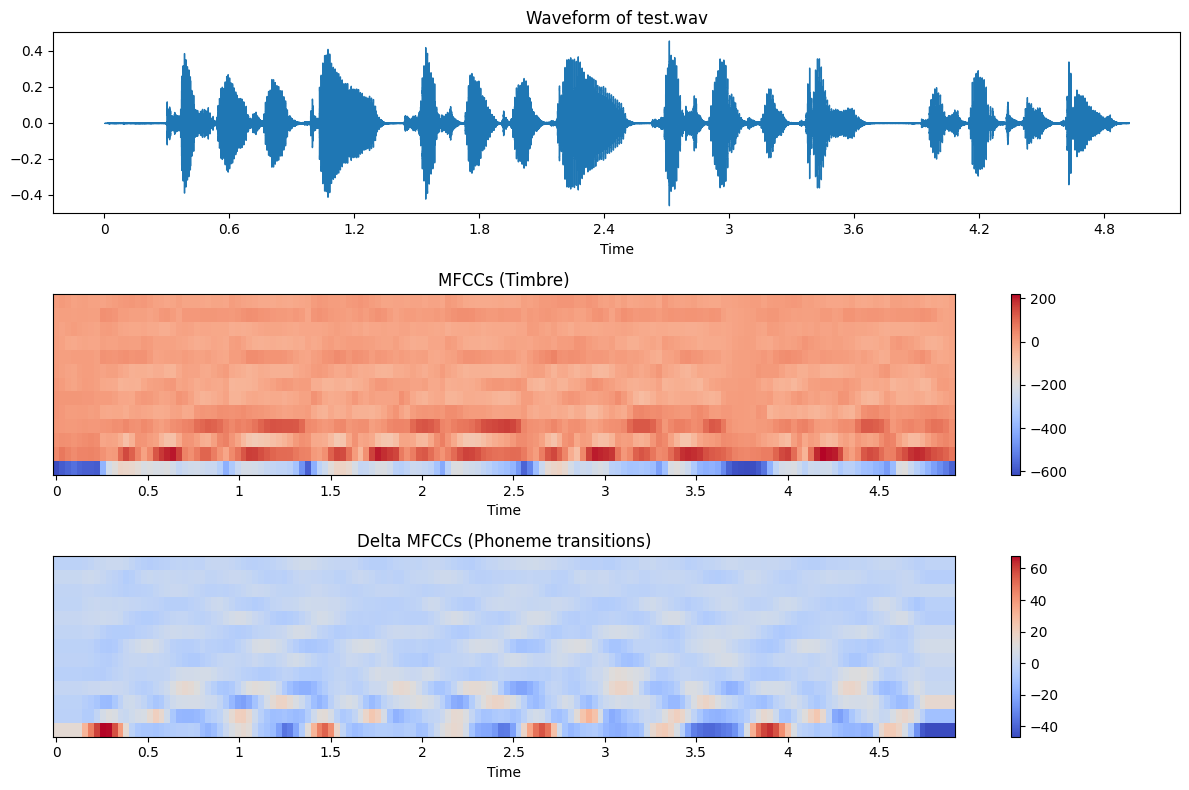


🔎 Enhanced Voice Similarity Analysis:
📂 Justin_sample1: 19.2% similarity — ❌ Fail
📂 Justin_sample2: 77.8% similarity — ❌ Fail
📂 Justin_sample3: 18.3% similarity — ❌ Fail
📂 Justin_sample4: 93.5% similarity — ✅ Pass
📂 Justin_sample5: 19.1% similarity — ❌ Fail
📂 Justin_sample6: 19.0% similarity — ❌ Fail
📂 Justin_sample7: 19.3% similarity — ❌ Fail
📂 Justin_sample8: 19.0% similarity — ❌ Fail
📂 Justin_sample9: 18.9% similarity — ❌ Fail
📂 Justin_sample10: 92.2% similarity — ✅ Pass
📂 Justin_sample11: 91.5% similarity — ✅ Pass
📂 Justin_sample12: 18.6% similarity — ❌ Fail
📂 Justin_sample13: 91.8% similarity — ✅ Pass
📂 Justin_sample14: 18.9% similarity — ❌ Fail
📂 Justin_sample15: 91.4% similarity — ✅ Pass
📂 Justin_sample16: 91.7% similarity — ✅ Pass
📂 Justin_sample17: 18.9% similarity — ❌ Fail
📂 Justin_sample18: 17.9% similarity — ❌ Fail
📂 Justin_sample19: 91.9% similarity — ✅ Pass
📂 Justin_sample20: 89.3% similarity — ❌ Fail

🏆 Top 5 Matches:
  Justin_sample4: 93.5%
  Justin_sample10: 92.2%
  J

In [ ]:
voice_authentication_enhanced(threshold=90)